# Clasificación de intervenciones en reuniones ágiles

Trabajo de título de Italo López Meza

En el presente Jupyter Notebook se realiza la clasificación de intervenciones provenientes de una reunión ágil. Para comenzar, se define una dataset creado artificialmente con un total de 1110 datos, que incluye todos los tipos de intervenciones, las cuales son: Pregunta, Respuesta, Sugerencia, Comentario y Retroalimentación. Además, se define el modelo de inteligencia artificial "distilbert-base-uncased" para su posterior entrenamiento.

Una vez hecha la lectura y preparación de dataset, se definen los conjuntos de prueba y de testeo que se utilizarán para el entrenamiento del modelo de inteligencia artificial. Luego, se entrena el modelo de inteligencia artificial utlizando el dataset y se evalúa mediante las métricas precisión, recall, F1-Score y support. Posteriomente, el modelo entrenado para la clasificación de las intervenciones de una reunión real transcrita a texto. Finalmente se muestras gráficos de los resultados obtenidos.

## 1. Configuración

In [1]:
data_path = r"C:\Users\italo\OneDrive\Escritorio\djangoproject\dataset_oficial.csv" #@param {type:"string"}
text_column_name = "Intervenciones" #@param {type:"string"}
label_column_name = "Tipo" #@param {type:"string"}

model_name = "distilbert-base-uncased" #@param {type:"string"}
test_size = 0.2 #@param {type:"number"}
num_labels = 5 #@param {type:"number"}

## 2. Leer y preparar el dataset

In [2]:
import pandas as pd

# Leer solo la primera fila para obtener los encabezados
df = pd.read_csv(data_path)
num_columns = len(df.columns)
print(f"El archivo CSV tiene {num_columns} columnas.")

# Leer algunas filas del archivo para verificar la estructura
df_sample = pd.read_csv(data_path, nrows=10)
print(df_sample)


El archivo CSV tiene 2 columnas.
                                      Intervenciones        Tipo
0  Empezamos con la historia de usuario: Yo como ...    Pregunta
1  Si, es importante. Creo que el acceso debe ser...   Respuesta
2  Claro, eso es fundamental. Que piensas sobre l...    Pregunta
3  Deberian estar bien categorizados y actualizad...  Sugerencia
4  Exactamente. Que tipo de recursos crees que so...    Pregunta
5  Creo que deberiamos enfocarnos en tener una bu...  Sugerencia
6   Y como propones que se actualicen esos recursos?    Pregunta
7  Podriamos tener un equipo dedicado a revisar y...  Sugerencia
8  Eso suena bien. Que nivel de complejidad le da...    Pregunta
9  Yo diria que un 3, es manejable pero requiere ...   Respuesta


In [3]:
df = pd.read_csv(data_path)

In [4]:
df.head()

,Intervenciones,Tipo
0,Empezamos con la historia de usuario: Yo como ...,Pregunta
1,"Si, es importante. Creo que el acceso debe ser...",Respuesta
2,"Claro, eso es fundamental. Que piensas sobre l...",Pregunta
3,Deberian estar bien categorizados y actualizad...,Sugerencia
4,Exactamente. Que tipo de recursos crees que so...,Pregunta


### Label Encoder

In [5]:
from sklearn import preprocessing

In [6]:
le = preprocessing.LabelEncoder()
le.fit(df[label_column_name].tolist())
df['labels'] = le.transform(df[label_column_name].tolist())
nombres_etiquetas = le.classes_ 
print(nombres_etiquetas)

['Comentario' 'Pregunta' 'Respuesta' 'Retroalimentacion' 'Sugerencia']


In [7]:
df.head()

,Intervenciones,Tipo,labels
0,Empezamos con la historia de usuario: Yo como ...,Pregunta,1
1,"Si, es importante. Creo que el acceso debe ser...",Respuesta,2
2,"Claro, eso es fundamental. Que piensas sobre l...",Pregunta,1
3,Deberian estar bien categorizados y actualizad...,Sugerencia,4
4,Exactamente. Que tipo de recursos crees que so...,Pregunta,1


### Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
df_train,df_test = train_test_split(df,test_size=test_size)

### Convert to Huggingface Dataset

In [10]:
from datasets import Dataset

In [11]:
train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

### Tokenizer

In [12]:
from transformers import AutoTokenizer

In [13]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    return tokenizer(examples[text_column_name], truncation=True)

In [14]:
tokenized_train = train_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/807 [00:00<?, ? examples/s]

In [15]:
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

## 3. Inicializar el modelo de clasificación

In [16]:
from transformers import AutoModelForSequenceClassification

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 4. Entrenar el modelo de clasificación

In [18]:
from transformers import DataCollatorWithPadding
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np

In [19]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [20]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [21]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy = "epoch",
    logging_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


In [22]:
unique_labels = np.unique(tokenized_train['labels'])
print("Unique labels in training data:", unique_labels)


Unique labels in training data: [0 1 2 3 4]


In [23]:
num_labels = len(unique_labels)
print(num_labels)

5


In [24]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [25]:
trainer.train()

  0%|          | 0/303 [00:00<?, ?it/s]

{'loss': 0.372, 'grad_norm': 0.06943991780281067, 'learning_rate': 0.00013333333333333334, 'epoch': 1.0}


  0%|          | 0/26 [00:00<?, ?it/s]

{'eval_loss': 0.18957065045833588, 'eval_accuracy': 0.9455445544554455, 'eval_runtime': 4.0099, 'eval_samples_per_second': 50.376, 'eval_steps_per_second': 6.484, 'epoch': 1.0}
{'loss': 0.0658, 'grad_norm': 0.021817848086357117, 'learning_rate': 6.666666666666667e-05, 'epoch': 2.0}


  0%|          | 0/26 [00:00<?, ?it/s]

{'eval_loss': 0.03719436004757881, 'eval_accuracy': 0.995049504950495, 'eval_runtime': 3.9035, 'eval_samples_per_second': 51.748, 'eval_steps_per_second': 6.661, 'epoch': 2.0}
{'loss': 0.0175, 'grad_norm': 0.011114743538200855, 'learning_rate': 0.0, 'epoch': 3.0}


  0%|          | 0/26 [00:00<?, ?it/s]

{'eval_loss': 0.0006767831509932876, 'eval_accuracy': 1.0, 'eval_runtime': 3.9152, 'eval_samples_per_second': 51.594, 'eval_steps_per_second': 6.641, 'epoch': 3.0}
{'train_runtime': 253.8055, 'train_samples_per_second': 9.539, 'train_steps_per_second': 1.194, 'train_loss': 0.15177064799632964, 'epoch': 3.0}


TrainOutput(global_step=303, training_loss=0.15177064799632964, metrics={'train_runtime': 253.8055, 'train_samples_per_second': 9.539, 'train_steps_per_second': 1.194, 'total_flos': 28776718421370.0, 'train_loss': 0.15177064799632964, 'epoch': 3.0})

In [26]:
trainer.save_model('spam_model')

## 5. Evaluar el modelo

Precisión, recall, F1-Score y support son métricas utilizadas para evaluar la calidad de un modelo de clasificación. 
La **precisión** mide la proporción de predicciones correctas entre todas las predicciones positivas realizadas 
El **recall** evalúa la proporción de instancias positivas correctamente identificadas entre todas las que eran realmente positivas. 
El **F1-Score** combina ambas métricas mediante su media armónica, siendo útil cuando se necesita un equilibrio entre precisión y recall, especialmente en casos de clases desbalanceadas. 
El **support** indica la cantidad de instancias verdaderas de cada clase, proporcionando información sobre la distribución de los datos.

In [27]:
from sklearn.metrics import classification_report

In [28]:
preds = trainer.predict(tokenized_train)
preds = np.argmax(preds[:3][0],axis=1)
GT = df_train['labels'].tolist()
print(classification_report(GT,preds))

  0%|          | 0/101 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       187
           1       1.00      1.00      1.00       179
           2       1.00      1.00      1.00       109
           3       1.00      1.00      1.00        82
           4       1.00      1.00      1.00       250

    accuracy                           1.00       807
   macro avg       1.00      1.00      1.00       807
weighted avg       1.00      1.00      1.00       807



In [29]:
preds = trainer.predict(tokenized_test)
preds = np.argmax(preds[:3][0],axis=1) #preds[:3][1]
GT = df_test['labels'].tolist()
print(classification_report(GT,preds))

  0%|          | 0/26 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        31
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        63

    accuracy                           1.00       202
   macro avg       1.00      1.00      1.00       202
weighted avg       1.00      1.00      1.00       202



## 6. Clasificación de un archivo

In [30]:
import json

with open(r'C:\Users\italo\OneDrive\Escritorio\djangoproject\Transcripciones\Transcription-01A.json', 'r') as f:
    data = json.load(f)

# Extraer las intervenciones
intervenciones = [segment['text'] for segment in data['segments']]
print(intervenciones)


[' ¿Quién la lee?', 'Tú.', 'La historia de usuario A. Yo como estudiante necesito ver mi horario semanal para conocer en qué horario y sala o laboratorio se dicta cada asignatura.', 'Entonces lo que tenemos que hacer es especificar cuál es la complejidad de esto y se lo podemos poner en un sprint de dos semanas.', 'Lo voy a leer de nuevo.', 'Yo como estudiante necesito ver mi horario semanal', ' Para conocer en qué horario y sala o laboratorio se dicta cada asignatura.', 'Entonces, el contenedor de servicios de asignaturas tiene que tener la información de la sala de clase.', 'Yo creo que lo primero que deberíamos hacer es modularizar y asignar tiempo.', 'Porque yo, por ejemplo, yo en Frontend tengo que hacer el calendario, tengo que hacer las vistas del calendario y tengo que hacer también por...', ' estudiante las vistas de cada uno de sus horarios dependiendo de la información que hay en el paquete.', 'Yo creo que ver si es agradable para el público y que sea funcional como la mayor

In [31]:
# Usar el tokenizador
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Preprocesar las intervenciones
tokenized_intervenciones = tokenizer(intervenciones, truncation=True, padding=True, return_tensors="pt")

In [32]:
from transformers import AutoModelForSequenceClassification

# Cargar el modelo entrenado
model = AutoModelForSequenceClassification.from_pretrained('spam_model', num_labels=5)

In [33]:
import numpy as np

# Hacer predicciones
outputs = model(**tokenized_intervenciones)
predictions = np.argmax(outputs.logits.detach().cpu().numpy(), axis=1)

In [34]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
le.fit(['Pregunta', 'Respuesta', 'Comentario', 'Retroalimentacion', 'Sugerencia'])

# Convertir predicciones a etiquetas
predicciones_etiquetas = le.inverse_transform(predictions)


In [35]:
for intervencion, prediccion in zip(intervenciones, predicciones_etiquetas):
    print(f"Intervención: {intervencion}")
    print(f"Predicción: {prediccion}\n")


Intervención:  ¿Quién la lee?
Predicción: Pregunta

Intervención: Tú.
Predicción: Comentario

Intervención: La historia de usuario A. Yo como estudiante necesito ver mi horario semanal para conocer en qué horario y sala o laboratorio se dicta cada asignatura.
Predicción: Respuesta

Intervención: Entonces lo que tenemos que hacer es especificar cuál es la complejidad de esto y se lo podemos poner en un sprint de dos semanas.
Predicción: Respuesta

Intervención: Lo voy a leer de nuevo.
Predicción: Comentario

Intervención: Yo como estudiante necesito ver mi horario semanal
Predicción: Respuesta

Intervención:  Para conocer en qué horario y sala o laboratorio se dicta cada asignatura.
Predicción: Sugerencia

Intervención: Entonces, el contenedor de servicios de asignaturas tiene que tener la información de la sala de clase.
Predicción: Sugerencia

Intervención: Yo creo que lo primero que deberíamos hacer es modularizar y asignar tiempo.
Predicción: Respuesta

Intervención: Porque yo, por 

## Gráficos de resultados

In [36]:
import pandas as pd
import plotly.express as px

# Función para convertir "HH:MM:SS.SS" a segundos
def time_to_seconds(time_str):
    h, m, s = map(float, time_str.split(':'))
    return h * 3600 + m * 60 + s

# Extraer las intervenciones y convertir los tiempos
intervenciones = []
for segment in data['segments']:
    intervenciones.append({
        'speaker': segment['speaker'],
        'start_time': time_to_seconds(segment['start_time']),
        'end_time': time_to_seconds(segment['end_time']),
        'text': segment['text']
    })

# Convertir a DataFrame
df = pd.DataFrame(intervenciones)

# Crear un gráfico de dispersión (scatter plot) para las intervenciones
fig = px.scatter(df, x="start_time", y="speaker", color="speaker", hover_data=["text"])
fig.update_layout(xaxis_title="Tiempo (segundos)", yaxis_title="Participante")
fig.show()

In [37]:
# Ruta para guardar el archivo HTML
output_path = r'C:\Users\italo\OneDrive\Escritorio\djangoproject\myapp\plotly_figure.html'

fig.write_html(output_path)

In [38]:
import plotly.graph_objects as go

# Extraer las intervenciones y convertir los tiempos
intervenciones_data = []
for i, segment in enumerate(data['segments']):
    intervenciones_data.append({
        'speaker': segment['speaker'],
        'start_time': time_to_seconds(segment['start_time']),
        'end_time': time_to_seconds(segment['end_time']),
        'intervention_type': predicciones_etiquetas[i]
    })

# Convertir a DataFrame
df_intervenciones = pd.DataFrame(intervenciones_data)

# Contar cuántas veces cada participante realiza un tipo de intervención
flow_counts = df_intervenciones.groupby(['speaker', 'intervention_type']).size().reset_index(name='count')

# Crear listas únicas de los participantes y los tipos de intervención
speakers = df_intervenciones['speaker'].unique().tolist()
intervention_types = df_intervenciones['intervention_type'].unique().tolist()

# Crear una lista de todos los nodos (speakers y tipos de intervención)
nodes = speakers + intervention_types

# Crear un diccionario para mapear cada nodo a un índice
node_indices = {node: idx for idx, node in enumerate(nodes)}

# Preparar los datos para el diagrama de Sankey
sources = flow_counts['speaker'].map(node_indices)
targets = flow_counts['intervention_type'].map(node_indices)
values = flow_counts['count']

# Crear el diagrama de Sankey
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

# Mostrar el diagrama
fig.show()

In [39]:
# Ruta para guardar el archivo HTML
output_path = r'C:\Users\italo\OneDrive\Escritorio\djangoproject\myapp\plotly_figure2.html'

fig.write_html(output_path)

In [40]:
# Revisar la distribución de las predicciones
unique, counts = np.unique(predicciones_etiquetas, return_counts=True)
print(dict(zip(unique, counts)))

{'Comentario': 42, 'Pregunta': 11, 'Respuesta': 42, 'Sugerencia': 24}


In [41]:
import pandas as pd
import plotly.express as px

# Extraer los segmentos
segments = data['segments']

# Crear un DataFrame con los datos
df = pd.DataFrame(segments)

# Convertir los tiempos de inicio y fin a segundos
def time_to_seconds(time_str):
    h, m, s = map(float, time_str.split(':'))
    return h * 3600 + m * 60 + s

df['start_time'] = df['start_time'].apply(time_to_seconds)
df['end_time'] = df['end_time'].apply(time_to_seconds)
df['duration'] = df['end_time'] - df['start_time']  # Calcular duración

# Crear el gráfico de dispersión usando Plotly
fig = px.scatter(
    df, 
    x='start_time', 
    y='duration', 
    color='speaker', 
    labels={'start_time': 'Tiempo de Inicio (segundos)', 'duration': 'Duración (segundos)'},
    hover_data=['text']  
)

fig.show()

# Guardar el gráfico como un archivo HTML
output_path = r'C:\Users\italo\OneDrive\Escritorio\djangoproject\myapp\plotly_figure3.html'
fig.write_html(output_path)

print("El gráfico se ha guardado correctamente en:", output_path)


El gráfico se ha guardado correctamente en: C:\Users\italo\OneDrive\Escritorio\djangoproject\myapp\plotly_figure3.html


In [42]:
import pandas as pd
import json

# Cargar el archivo JSON
with open(r'C:\Users\italo\OneDrive\Escritorio\djangoproject\Transcripciones\Transcription-01A.json', 'r') as f:
    data = json.load(f)

# Extraer las intervenciones
intervenciones_data = []
for i, segment in enumerate(data['segments']):
    intervention_type = predicciones_etiquetas[i] if i < len(predicciones_etiquetas) else 'Desconocido'  
    intervenciones_data.append({
        'speaker': segment['speaker'],
        'start_time': time_to_seconds(segment['start_time']),
        'end_time': time_to_seconds(segment['end_time']),
        'duration': time_to_seconds(segment['end_time']) - time_to_seconds(segment['start_time']),
        'intervention_type': intervention_type
    })

# Convertir a DataFrame
df_intervenciones = pd.DataFrame(intervenciones_data)

# Crear la tabla resumen
resumen = df_intervenciones.groupby('speaker').agg(
    numero_intervenciones=('intervention_type', 'size'),  # Cuenta cuántas intervenciones tiene cada speaker
    tiempo_total=('duration', 'sum'),  # Suma la duración total
    preguntas=('intervention_type', lambda x: (x == 'Pregunta').sum()),  # Cuenta preguntas
    respuestas=('intervention_type', lambda x: (x == 'Respuesta').sum()),  # Cuenta respuestas
    comentarios=('intervention_type', lambda x: (x == 'Comentario').sum()),  # Cuenta comentarios
    retroalimentaciones=('intervention_type', lambda x: (x == 'Retroalimentacion').sum()),  # Cuenta retroalimentaciones
    sugerencias=('intervention_type', lambda x: (x == 'Sugerencia').sum())  # Cuenta sugerencias
).reset_index()

# Redondear las columnas para una mejor presentación
resumen = resumen.round({'tiempo_total': 2})

# Mostrar la tabla con Pandas
display(resumen)

# Supongamos que tu DataFrame de resumen es 'resumen'
resumen.to_csv(r'C:\Users\italo\OneDrive\Escritorio\djangoproject\myapp\resumen_intervenciones.csv', index=False)


,speaker,numero_intervenciones,tiempo_total,preguntas,respuestas,comentarios,retroalimentaciones,sugerencias
0,SPEAKER_00,72,275.83,7,27,18,0,20
1,SPEAKER_01,25,70.14,1,9,12,0,3
2,SPEAKER_02,13,38.42,2,3,8,0,0
3,SPEAKER_03,9,35.82,1,3,4,0,1


In [43]:
resumen.to_csv('resumen_intervenciones.csv', index=False)

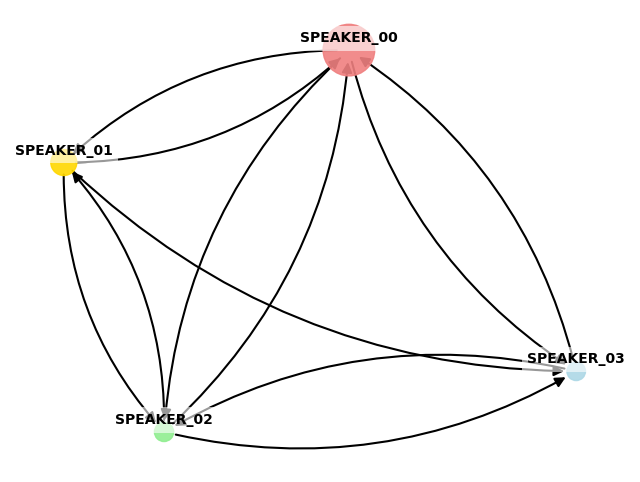

In [47]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Extraer las intervenciones y convertir los tiempos
intervenciones_data = []
for i, segment in enumerate(data['segments']):
    intervenciones_data.append({
        'speaker': segment['speaker'],
        'start_time': time_to_seconds(segment['start_time']),
        'end_time': time_to_seconds(segment['end_time']),
        'duration': time_to_seconds(segment['end_time']) - time_to_seconds(segment['start_time']),
        'intervention_type': predicciones_etiquetas[i]  
    })

# Convertir a DataFrame
df_intervenciones = pd.DataFrame(intervenciones_data)

# Calcular la duración total de habla por participante
duracion_total = df_intervenciones.groupby('speaker')['duration'].sum().to_dict()

# Crear el grafo dirigido utilizando NetworkX
G = nx.DiGraph()

# Agregar nodos y aristas basadas en las interacciones
previous_speaker = None
for index, row in df_intervenciones.iterrows():
    current_speaker = row['speaker']
    intervention_type = row['intervention_type']
    
    # Agregar nodo si no existe
    if current_speaker not in G:
        G.add_node(current_speaker, duration=duracion_total[current_speaker])
    
    # Crear una conexión si hay un cambio de speaker (interacción entre dos participantes)
    if previous_speaker and previous_speaker != current_speaker:
        if G.has_edge(previous_speaker, current_speaker):
            # Si ya existe la arista, incrementar el contador para este tipo de intervención
            if intervention_type in G[previous_speaker][current_speaker]['tipo']:
                G[previous_speaker][current_speaker]['tipo'][intervention_type] += 1
            else:
                G[previous_speaker][current_speaker]['tipo'][intervention_type] = 1
        else:
            # Crear una nueva arista con el tipo de intervención
            G.add_edge(previous_speaker, current_speaker, tipo={intervention_type: 1})
    
    # Actualizar el speaker previo
    previous_speaker = current_speaker

# Dibujar el grafo
plt.figure(figsize=(8, 6))  

# Posicionar los nodos usando un layout
pos = nx.spring_layout(G, seed=42)

# Escalar el tamaño del nodo según la duración de intervención
node_sizes = [G.nodes[node]['duration'] * 5 for node in G]  

# Dibujar nodos con colores personalizados
colors = ['lightcoral', 'lightblue', 'lightgreen', 'gold']
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=colors, alpha=0.9)

# Dibujar aristas con flechas y colores más destacables
for u, v, d in G.edges(data=True):
    # Dibujar cada tipo de intervención como una flecha más visible
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        width=1.5,  
        arrowstyle='-|>', 
        arrowsize=15, 
        edge_color='black',  
        connectionstyle='arc3,rad=0.2'  
    )

# Etiquetas de los nodos por fuera del círculo
for node, (x, y) in pos.items():
    plt.text(
        x, y + 0.03, 
        s=node,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
        horizontalalignment='center', fontsize=10, fontweight='bold', color='black'
    )
plt.axis('off')

output_path = r'C:\Users\italo\OneDrive\Escritorio\djangoproject\myapp\static\interacciones.png'
plt.savefig(output_path, format='png', bbox_inches='tight')

plt.show()